In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import pickle
import os

# =====================================================
# CONFIGURATION: Hyperparameters and device setup
# =====================================================

LATENT_DIM = 16  # Dimension of latent space (compressed representation)
BATCH_SIZE = 64  # Images per batch during training
LR = 1e-3  # Learning rate for Adam optimizer
EPOCHS = 50  # Number of complete passes through dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")
print(f"Configuration: LATENT_DIM={LATENT_DIM}, BATCH_SIZE={BATCH_SIZE}, LR={LR}, EPOCHS={EPOCHS}")

# =====================================================
# HISTORY TRACKING: Data structure for storing training metrics
# =====================================================

# Dictionary to store all training history for later visualization
training_history = {
    'epoch': [],
    'total_loss': [],
    'recon_loss': [],
    'kld_loss': [],
    'avg_loss': [],
    'batch_losses': []  # Store per-batch losses for detailed analysis
}


# =====================================================
# VAE MODEL: Variational Autoencoder architecture
# =====================================================

class VAE(nn.Module):
    """
    Variational Autoencoder for MNIST digit generation and reconstruction.

    Theory:
        - Encoder: Compresses image to latent space (mean and variance)
        - Reparameterization: Samples latent code from learned distribution
        - Decoder: Reconstructs image from latent code
        - Loss: Reconstruction loss + KL divergence (forces clean latent space)

    Architecture:
        Encoder: Conv(1->32) -> Conv(32->64) -> Flatten -> Linear(3136->latent)
        Decoder: Linear(latent->3136) -> ConvTranspose(64->32) -> ConvTranspose(32->1)
    """

    def __init__(self, latent_dim):
        """
        Initialize VAE with encoder and decoder networks.

        Parameters:
            latent_dim: Dimension of latent space (e.g., 16, 32, 64)
        """
        super(VAE, self).__init__()

        # === ENCODER: Compress 28x28 image to latent vector ===
        # Input: [B, 1, 28, 28]
        # Output: [B, latent_dim]
        self.encoder = nn.Sequential(
            # Conv layer 1: 1 channel -> 32 channels, 28x28 -> 14x14
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Conv layer 2: 32 channels -> 64 channels, 14x14 -> 7x7
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Flatten: [B, 64, 7, 7] -> [B, 3136]
            nn.Flatten()
        )

        # === LATENT SPACE PROJECTION ===
        # From flattened features [B, 3136] to latent parameters
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)  # Mean of latent distribution
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)  # Log variance (for numerical stability)

        # === DECODER: Reconstruct image from latent vector ===
        # Input after linear: [B, 3136] (reshaped to [B, 64, 7, 7])
        # Output: [B, 1, 28, 28]
        self.decoder_input = nn.Linear(latent_dim, 64 * 7 * 7)  # Expand latent to 3136
        self.decoder = nn.Sequential(
            # Unflatten: [B, 3136] -> [B, 64, 7, 7]
            nn.Unflatten(1, (64, 7, 7)),
            # ConvTranspose layer 1: 64 channels -> 32, 7x7 -> 14x14
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # ConvTranspose layer 2: 32 channels -> 1, 14x14 -> 28x28
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            # Sigmoid: Squeeze output to [0, 1] range for pixel values
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: Sample from latent distribution.

        Theory: Instead of sampling z ~ N(mu, logvar) directly,
        we sample eps ~ N(0, 1) and compute z = mu + std * eps.
        This allows gradients to flow during backpropagation.

        Parameters:
            mu: Mean of latent distribution, shape [B, latent_dim]
            logvar: Log variance of latent distribution, shape [B, latent_dim]

        Returns:
            z: Sampled latent code, shape [B, latent_dim]
        """
        # Convert logvar to standard deviation: std = exp(0.5 * logvar)
        std = torch.exp(0.5 * logvar)
        # Sample epsilon from standard normal distribution
        eps = torch.randn_like(std)
        # Reparameterization: z = mu + std * eps
        z = mu + eps * std
        return z

    def forward(self, x):
        """
        Forward pass through VAE.

        Parameters:
            x: Input images, shape [B, 1, 28, 28], values in [0, 1]

        Returns:
            x_recon: Reconstructed images, shape [B, 1, 28, 28], values in [0, 1]
            mu: Mean of latent distribution, shape [B, latent_dim]
            logvar: Log variance of latent distribution, shape [B, latent_dim]
        """
        # === ENCODER: Compress image to latent parameters ===
        h = self.encoder(x)  # [B, 1, 28, 28] -> [B, 3136]

        # === LATENT SPACE ===
        mu = self.fc_mu(h)  # [B, 3136] -> [B, latent_dim] (mean)
        logvar = self.fc_logvar(h)  # [B, 3136] -> [B, latent_dim] (log variance)

        # === REPARAMETERIZATION ===
        z = self.reparameterize(mu, logvar)  # Sample latent code [B, latent_dim]

        # === DECODER: Reconstruct image from latent ===
        decoder_input = self.decoder_input(z)  # [B, latent_dim] -> [B, 3136]
        x_recon = self.decoder(decoder_input)  # [B, 3136] -> [B, 1, 28, 28]

        return x_recon, mu, logvar


# =====================================================
# LOSS FUNCTION: ELBO (Evidence Lower Bound)
# =====================================================

def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """
    Compute VAE loss (ELBO): Reconstruction loss + KL divergence.

    Theory:
        - Reconstruction Loss: BCE measures how well decoder reconstructs input
        - KL Divergence: Regularizes latent space to be close to N(0,1)
        - Beta: Hyperparameter to balance reconstruction vs regularization (β=1 default)

    Parameters:
        recon_x: Reconstructed images, shape [B, 1, 28, 28]
        x: Original images, shape [B, 1, 28, 28]
        mu: Mean of latent distribution, shape [B, latent_dim]
        logvar: Log variance of latent distribution, shape [B, latent_dim]
        beta: Weighting factor for KL divergence (default: 1.0)

    Returns:
        Dictionary containing:
            - 'loss': Total loss (reconstruction + weighted KL)
            - 'recon_loss': Reconstruction loss
            - 'kld_loss': KL divergence loss
    """
    # === RECONSTRUCTION LOSS ===
    # Binary Cross Entropy for pixel-by-pixel reconstruction on [0, 1]
    # Measures: "How well does the reconstruction match the input?"
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # === KL DIVERGENCE LOSS ===
    # Forces latent distribution to be close to standard normal N(0, 1)
    # Formula: KL(N(mu, logvar) || N(0, 1)) = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    # Measures: "How much do our learned latent codes deviate from standard normal?"
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # === TOTAL LOSS ===
    # Combine reconstruction and regularization
    total_loss = recon_loss + beta * kld_loss

    return {
        'loss': total_loss,
        'recon_loss': recon_loss.item(),
        'kld_loss': kld_loss.item()
    }


Using device: cuda
Configuration: LATENT_DIM=16, BATCH_SIZE=64, LR=0.001, EPOCHS=50


In [2]:
# =====================================================
# DATASET PREPARATION: Load MNIST training and validation data
# =====================================================

# Define image transformations
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL Image to tensor, scale to [0, 1]
])

# Load MNIST training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load MNIST test dataset (use as validation)
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create DataLoaders for batching
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Dataset loaded:")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Validation samples: {len(test_dataset)}")
print(f"  Batches per epoch: {len(train_loader)}")

# =====================================================
# INITIALIZE MODEL, OPTIMIZER
# =====================================================

# Create VAE model and move to device
model = VAE(latent_dim=LATENT_DIM).to(device)

# Adam optimizer: Adaptive learning rate optimizer
optimizer = optim.Adam(model.parameters(), lr=LR)

print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]


Dataset loaded:
  Training samples: 60000
  Validation samples: 10000
  Batches per epoch: 938
Model initialized with 191,265 parameters


In [3]:
# =====================================================
# TRAINING LOOP: Train VAE with comprehensive history tracking
# =====================================================

print("\nStarting Training...")
print("="*70)

# Outer loop: iterate over epochs
for epoch in range(EPOCHS):
    # === TRAINING PHASE ===
    model.train()

    train_total_loss = 0.0
    train_recon_loss = 0.0
    train_kld_loss = 0.0
    batch_losses_epoch = []

    # Inner loop: iterate over training batches
    for batch_idx, (x, _) in enumerate(train_loader):
        # Move images to device
        x = x.to(device)

        # Forward pass: get reconstructions and latent parameters
        x_recon, mu, logvar = model(x)

        # Compute loss with detailed breakdown
        loss_dict = vae_loss(x_recon, x, mu, logvar, beta=1.0)
        loss = loss_dict['loss']

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate losses
        train_total_loss += loss.item()
        train_recon_loss += loss_dict['recon_loss']
        train_kld_loss += loss_dict['kld_loss']
        batch_losses_epoch.append(loss.item())

    # === VALIDATION PHASE ===
    model.eval()
    val_total_loss = 0.0
    val_recon_loss = 0.0
    val_kld_loss = 0.0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            x_recon, mu, logvar = model(x)
            loss_dict = vae_loss(x_recon, x, mu, logvar, beta=1.0)
            val_total_loss += loss_dict['loss'].item()
            val_recon_loss += loss_dict['recon_loss']
            val_kld_loss += loss_dict['kld_loss']

    # === CALCULATE AVERAGES ===
    num_train_batches = len(train_loader)
    num_val_samples = len(test_dataset)
    num_train_samples = len(train_dataset)

    avg_train_loss = train_total_loss / num_train_samples
    avg_train_recon = train_recon_loss / num_train_samples
    avg_train_kld = train_kld_loss / num_train_samples

    avg_val_loss = val_total_loss / num_val_samples
    avg_val_recon = val_recon_loss / num_val_samples
    avg_val_kld = val_kld_loss / num_val_samples

    # === STORE HISTORY ===
    training_history['epoch'].append(epoch + 1)
    training_history['total_loss'].append(avg_train_loss)
    training_history['recon_loss'].append(avg_train_recon)
    training_history['kld_loss'].append(avg_train_kld)
    training_history['avg_loss'].append(avg_train_loss)
    training_history['batch_losses'].append(batch_losses_epoch)

    # Add validation metrics if not already in history
    if 'val_loss' not in training_history:
        training_history['val_loss'] = []
        training_history['val_recon'] = []
        training_history['val_kld'] = []

    training_history['val_loss'].append(avg_val_loss)
    training_history['val_recon'].append(avg_val_recon)
    training_history['val_kld'].append(avg_val_kld)

    # === PRINT PROGRESS ===
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:2d}/{EPOCHS}]")
        print(f"  Train - Loss: {avg_train_loss:.6f} | Recon: {avg_train_recon:.6f} | KLD: {avg_train_kld:.6f}")
        print(f"  Val   - Loss: {avg_val_loss:.6f} | Recon: {avg_val_recon:.6f} | KLD: {avg_val_kld:.6f}")

print("="*70)
print("Training Complete!")
print(f"\nFinal Training Loss: {training_history['total_loss'][-1]:.6f}")
print(f"Final Validation Loss: {training_history['val_loss'][-1]:.6f}")


Starting Training...
Epoch [ 1/50]
  Train - Loss: 148.634966 | Recon: 126.034588 | KLD: 22.600378
  Val   - Loss: 120.701394 | Recon: 95.946713 | KLD: 24.754681
Epoch [ 5/50]
  Train - Loss: 107.506355 | Recon: 83.251427 | KLD: 24.254928
  Val   - Loss: 106.647230 | Recon: 82.457315 | KLD: 24.189914
Epoch [10/50]
  Train - Loss: 104.463819 | Recon: 80.186975 | KLD: 24.276844
  Val   - Loss: 103.598228 | Recon: 79.666182 | KLD: 23.932046
Epoch [15/50]
  Train - Loss: 103.065180 | Recon: 78.836984 | KLD: 24.228196
  Val   - Loss: 102.691560 | Recon: 78.817584 | KLD: 23.873977
Epoch [20/50]
  Train - Loss: 102.170633 | Recon: 78.014074 | KLD: 24.156559
  Val   - Loss: 101.944124 | Recon: 78.003707 | KLD: 23.940416
Epoch [25/50]
  Train - Loss: 101.615962 | Recon: 77.467854 | KLD: 24.148108
  Val   - Loss: 101.237524 | Recon: 76.782575 | KLD: 24.454949
Epoch [30/50]
  Train - Loss: 101.191939 | Recon: 77.066807 | KLD: 24.125132
  Val   - Loss: 100.828573 | Recon: 77.266246 | KLD: 23.5623

Training history saved to: ./training_results/vae_training_history.pkl
Model saved to: ./training_results/vae_model.pth


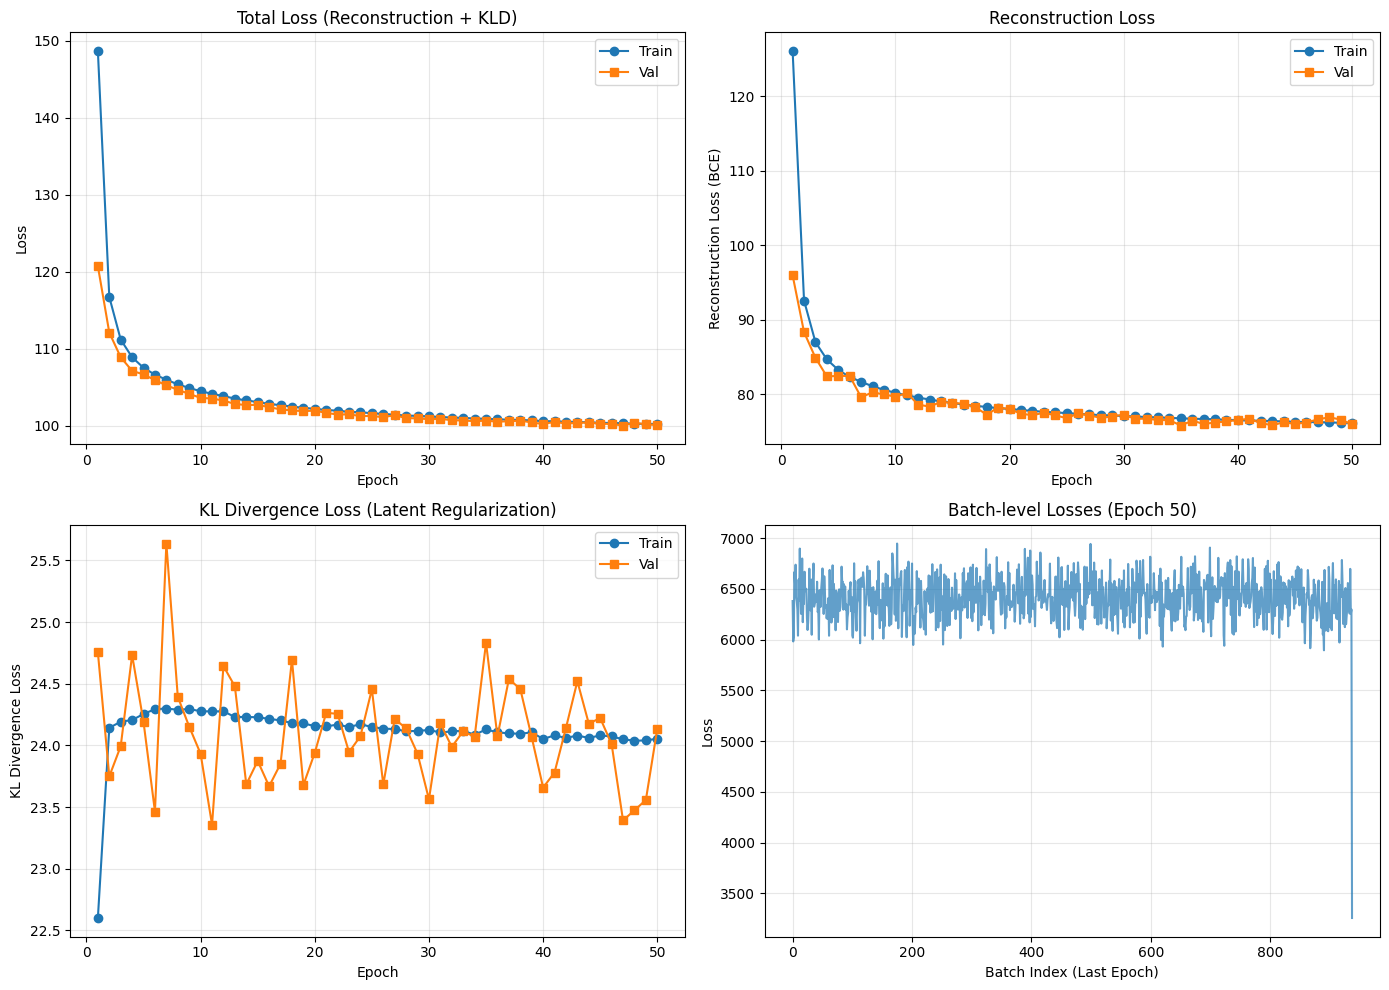

Training curves saved to: ./training_results/training_curves.png

✓ All training data and visualizations saved!


In [4]:
# =====================================================
# SAVE TRAINING HISTORY AND MODEL
# =====================================================

# Create directory for results if it doesn't exist
os.makedirs('./training_results', exist_ok=True)

# Save training history as pickle (for later loading)
history_path = './training_results/vae_training_history.pkl'
with open(history_path, 'wb') as f:
    pickle.dump(training_history, f)
print(f"Training history saved to: {history_path}")

# Save model checkpoint
model_path = './training_results/vae_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': EPOCHS,
    'latent_dim': LATENT_DIM,
    'config': {
        'LATENT_DIM': LATENT_DIM,
        'BATCH_SIZE': BATCH_SIZE,
        'LR': LR,
        'EPOCHS': EPOCHS
    }
}, model_path)
print(f"Model saved to: {model_path}")

# =====================================================
# QUICK VISUALIZATION: Training curves
# =====================================================

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Total Loss
axes[0, 0].plot(training_history['epoch'], training_history['total_loss'], label='Train', marker='o')
axes[0, 0].plot(training_history['epoch'], training_history['val_loss'], label='Val', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Total Loss (Reconstruction + KLD)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Reconstruction Loss
axes[0, 1].plot(training_history['epoch'], training_history['recon_loss'], label='Train', marker='o')
axes[0, 1].plot(training_history['epoch'], training_history['val_recon'], label='Val', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Reconstruction Loss (BCE)')
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: KLD Loss
axes[1, 0].plot(training_history['epoch'], training_history['kld_loss'], label='Train', marker='o')
axes[1, 0].plot(training_history['epoch'], training_history['val_kld'], label='Val', marker='s')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('KL Divergence Loss')
axes[1, 0].set_title('KL Divergence Loss (Latent Regularization)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Last epoch batch losses
axes[1, 1].plot(training_history['batch_losses'][-1], alpha=0.7)
axes[1, 1].set_xlabel('Batch Index (Last Epoch)')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title(f'Batch-level Losses (Epoch {EPOCHS})')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./training_results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to: ./training_results/training_curves.png")
print("\n✓ All training data and visualizations saved!")

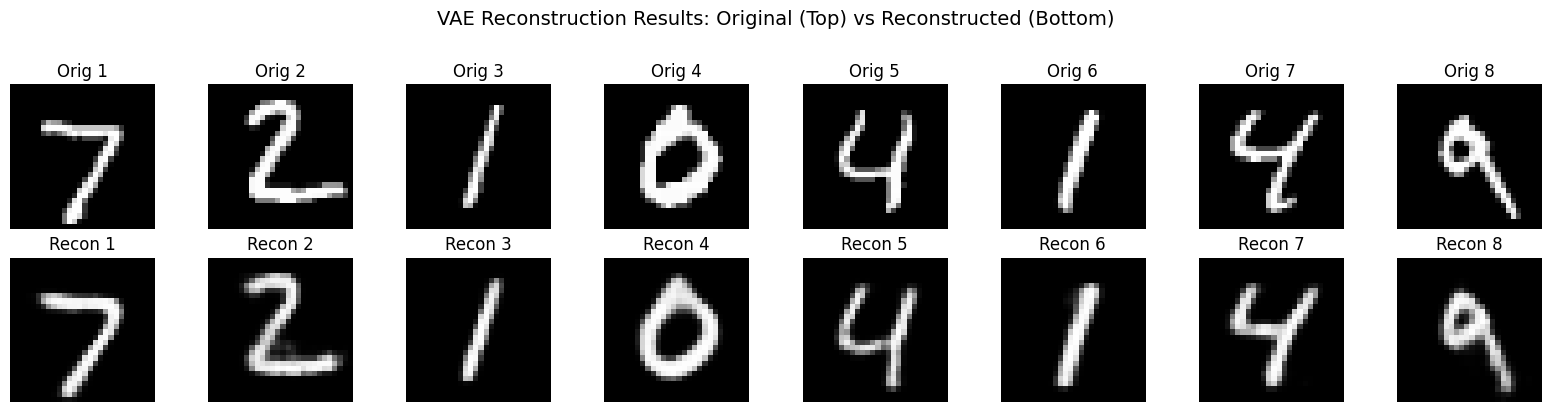

Reconstruction visualization saved to: ./training_results/reconstructions.png


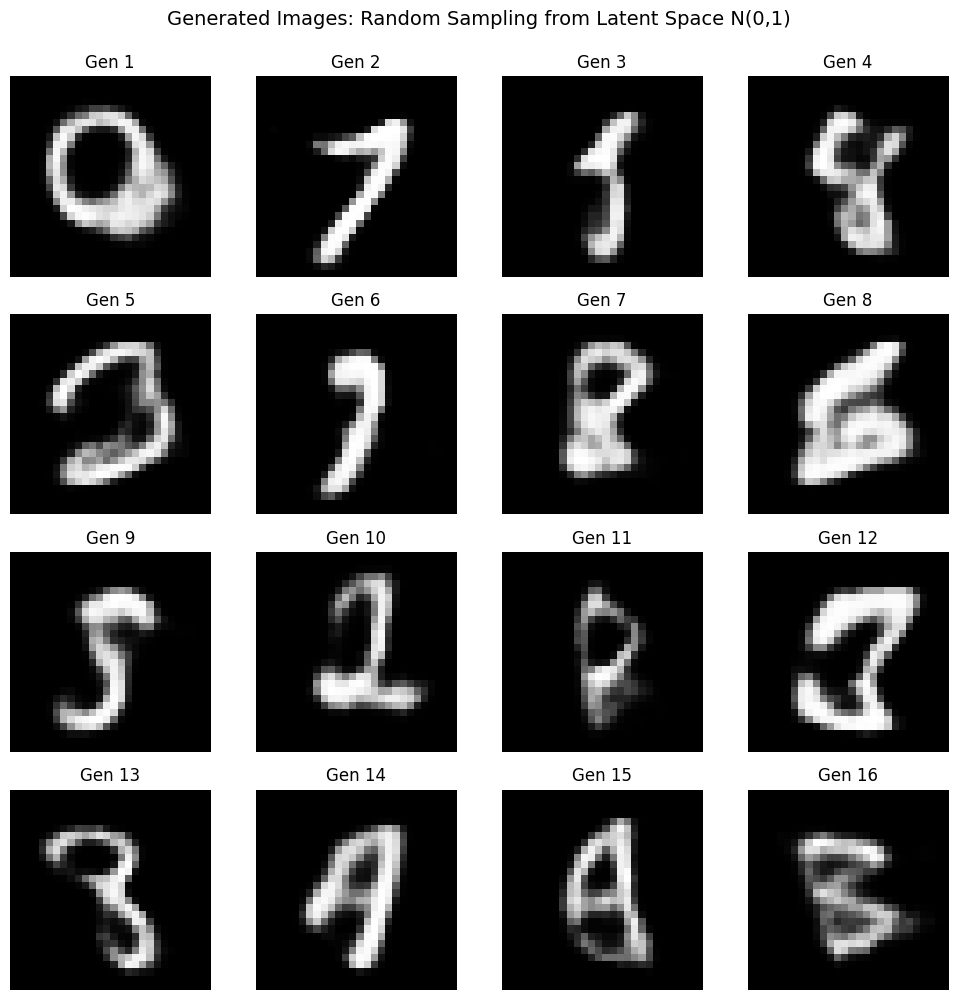

Generated images saved to: ./training_results/generated_images.png

All visualizations complete!


In [5]:
# =====================================================
# VISUALIZATION: Reconstructions and latent space exploration
# =====================================================

# Set model to evaluation mode
model.eval()

# === RECONSTRUCTION VISUALIZATION ===
# Show original vs reconstructed images
with torch.no_grad():
    # Get a batch of images
    x_orig, _ = next(iter(val_loader))
    x_orig = x_orig.to(device)

    # Forward pass
    x_recon, mu, logvar = model(x_orig)

    # Create figure: Original and Reconstructed
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))

    for idx in range(8):
        # Original images
        axes[0, idx].imshow(x_orig[idx].cpu().squeeze(), cmap='gray')
        axes[0, idx].set_title(f"Orig {idx+1}")
        axes[0, idx].axis('off')

        # Reconstructed images
        axes[1, idx].imshow(x_recon[idx].cpu().squeeze(), cmap='gray')
        axes[1, idx].set_title(f"Recon {idx+1}")
        axes[1, idx].axis('off')

    fig.suptitle("VAE Reconstruction Results: Original (Top) vs Reconstructed (Bottom)",
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('./training_results/reconstructions.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Reconstruction visualization saved to: ./training_results/reconstructions.png")

# === LATENT SPACE GENERATION ===
# Generate new images by sampling from latent space
with torch.no_grad():
    # Sample random latent codes from standard normal
    z_random = torch.randn(16, LATENT_DIM).to(device)

    # Decode to generate images
    decoder_input = model.decoder_input(z_random)
    generated = model.decoder(decoder_input)

    # Plot generated images
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))

    for idx in range(16):
        row, col = idx // 4, idx % 4
        axes[row, col].imshow(generated[idx].cpu().squeeze(), cmap='gray')
        axes[row, col].set_title(f"Gen {idx+1}")
        axes[row, col].axis('off')

    fig.suptitle("Generated Images: Random Sampling from Latent Space N(0,1)",
                 fontsize=14, y=0.995)
    plt.tight_layout()
    plt.savefig('./training_results/generated_images.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Generated images saved to: ./training_results/generated_images.png")

print("\nAll visualizations complete!")